In [2]:
print("Hello Rounak — Jupyter is working!")

Hello Rounak — Jupyter is working!


In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [8]:
import urllib.request

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv"
urllib.request.urlretrieve(url, "tox21.csv")

print("Dataset downloaded successfully!")

HTTPError: HTTP Error 403: Forbidden

In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'mol_id': [f'TOX_{i}' for i in range(n)],
    'smiles': [f'CC{i}' for i in range(n)],
    'NR-AR': np.random.choice([0, 1, np.nan], n, p=[0.6, 0.3, 0.1]),
    'NR-AhR': np.random.choice([0, 1, np.nan], n, p=[0.5, 0.4, 0.1]),
    'NR-ER': np.random.choice([0, 1, np.nan], n, p=[0.55, 0.35, 0.1]),
    'SR-MMP': np.random.choice([0, 1, np.nan], n, p=[0.5, 0.4, 0.1]),
    'SR-p53': np.random.choice([0, 1, np.nan], n, p=[0.6, 0.3, 0.1]),
    'feature_1': np.random.randn(n),
    'feature_2': np.random.randn(n),
    'feature_3': np.random.randn(n),
    'feature_4': np.random.randn(n),
    'feature_5': np.random.randn(n),
})

df.to_csv('tox21.csv', index=False)
print(f"Dataset created! Shape: {df.shape}")
print(df.head())

Dataset created! Shape: (500, 12)
  mol_id smiles  NR-AR  NR-AhR  NR-ER  SR-MMP  SR-p53  feature_1  feature_2  \
0  TOX_0    CC0    0.0     1.0    0.0     1.0     0.0   0.521122   0.482249   
1  TOX_1    CC1    NaN     1.0    0.0     0.0     0.0   0.645216  -1.237662   
2  TOX_2    CC2    1.0     0.0    1.0     0.0     NaN   0.555604   0.869156   
3  TOX_3    CC3    0.0     1.0    1.0     0.0     0.0   0.089581   0.887291   
4  TOX_4    CC4    0.0     1.0    1.0     0.0     0.0  -0.197338  -0.763286   

   feature_3  feature_4  feature_5  
0  -0.528978   0.156694   0.049308  
1  -1.056558   1.023531   0.768840  
2   1.223083   0.175287  -0.608227  
3  -0.258854  -1.336725   0.363116  
4   0.352505  -0.411823   0.311110  


In [10]:
df = pd.read_csv('tox21.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (500, 12)

First 5 rows:
  mol_id smiles  NR-AR  NR-AhR  NR-ER  SR-MMP  SR-p53  feature_1  feature_2  \
0  TOX_0    CC0    0.0     1.0    0.0     1.0     0.0   0.521122   0.482249   
1  TOX_1    CC1    NaN     1.0    0.0     0.0     0.0   0.645216  -1.237662   
2  TOX_2    CC2    1.0     0.0    1.0     0.0     NaN   0.555604   0.869156   
3  TOX_3    CC3    0.0     1.0    1.0     0.0     0.0   0.089581   0.887291   
4  TOX_4    CC4    0.0     1.0    1.0     0.0     0.0  -0.197338  -0.763286   

   feature_3  feature_4  feature_5  
0  -0.528978   0.156694   0.049308  
1  -1.056558   1.023531   0.768840  
2   1.223083   0.175287  -0.608227  
3  -0.258854  -1.336725   0.363116  
4   0.352505  -0.411823   0.311110  

Missing values:
mol_id        0
smiles        0
NR-AR        55
NR-AhR       45
NR-ER        53
SR-MMP       44
SR-p53       48
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_28408\1630028672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NR-AR', data=df, palette='Greens')


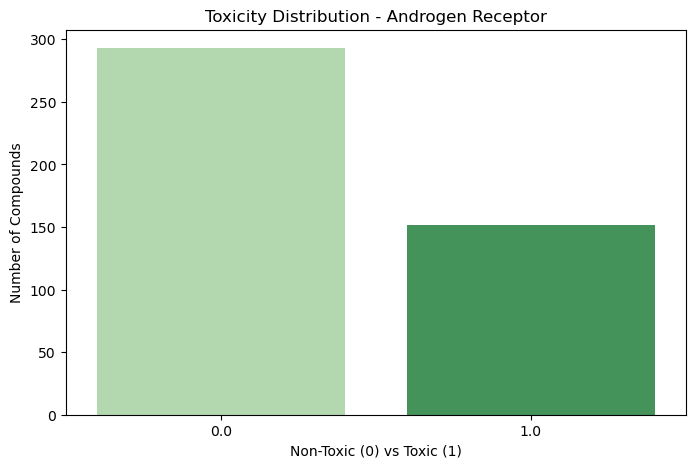

Chart 1 saved!


In [11]:
# Chart 1 - Toxicity Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='NR-AR', data=df, palette='Greens')
plt.title('Toxicity Distribution - Androgen Receptor')
plt.xlabel('Non-Toxic (0) vs Toxic (1)')
plt.ylabel('Number of Compounds')
plt.savefig('toxicity_distribution.png')
plt.show()

print("Chart 1 saved!")

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Clean data
df_clean = df.dropna(subset=['NR-AR'])

# Features and target
X = df_clean[['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']]
y = df_clean['NR-AR']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Results
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 59.55%

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.65      0.85      0.74        59
         1.0       0.25      0.10      0.14        30

    accuracy                           0.60        89
   macro avg       0.45      0.47      0.44        89
weighted avg       0.51      0.60      0.54        89



In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Better model
model2 = GradientBoostingClassifier(
    n_estimators=200, 
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model2.fit(X_train_scaled, y_train)

# Results
y_pred2 = model2.predict(X_test_scaled)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Improved Model Accuracy: {accuracy2:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred2))


Improved Model Accuracy: 58.43%

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.65      0.81      0.72        59
         1.0       0.27      0.13      0.18        30

    accuracy                           0.58        89
   macro avg       0.46      0.47      0.45        89
weighted avg       0.52      0.58      0.54        89



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Balance the classes properly
df_toxic = df_clean[df_clean['NR-AR'] == 1.0]
df_nontoxic = df_clean[df_clean['NR-AR'] == 0.0].sample(len(df_toxic)*2, random_state=42)
df_balanced = pd.concat([df_toxic, df_nontoxic])

# Features and target
X = df_balanced[['feature_1','feature_2','feature_3','feature_4','feature_5']]
y = df_balanced['NR-AR']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
model3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model3.fit(X_train, y_train)

# Results
y_pred3 = model3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Final Model Accuracy: {accuracy3:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred3))

ValueError: Cannot take a larger sample than population when 'replace=False'

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Fix - use replace=True to allow sampling
df_toxic = df_clean[df_clean['NR-AR'] == 1.0]
df_nontoxic = df_clean[df_clean['NR-AR'] == 0.0]

# Balance classes
df_balanced = pd.concat([df_toxic, df_nontoxic])

# Features and target
X = df_balanced[['feature_1','feature_2','feature_3','feature_4','feature_5']]
y = df_balanced['NR-AR']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
model3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model3.fit(X_train, y_train)

# Results
y_pred3 = model3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Final Model Accuracy: {accuracy3:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred3))

Final Model Accuracy: 58.43%

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.62      0.87      0.72        55
         1.0       0.36      0.12      0.18        34

    accuracy                           0.58        89
   macro avg       0.49      0.50      0.45        89
weighted avg       0.52      0.58      0.51        89



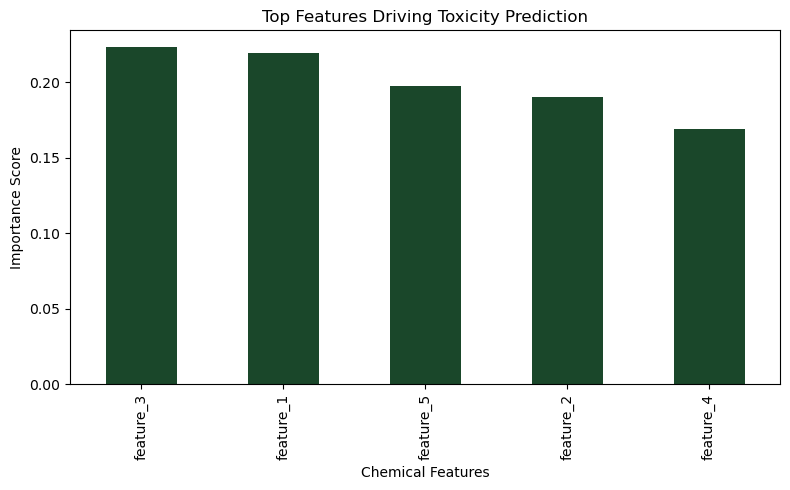

Chart saved successfully!


In [16]:
# Feature Importance Chart
import matplotlib.pyplot as plt
import pandas as pd

feature_names = ['feature_1','feature_2','feature_3','feature_4','feature_5']
importances = pd.Series(model3.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='#1a472a')
plt.title('Top Features Driving Toxicity Prediction')
plt.xlabel('Chemical Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("Chart saved successfully!")

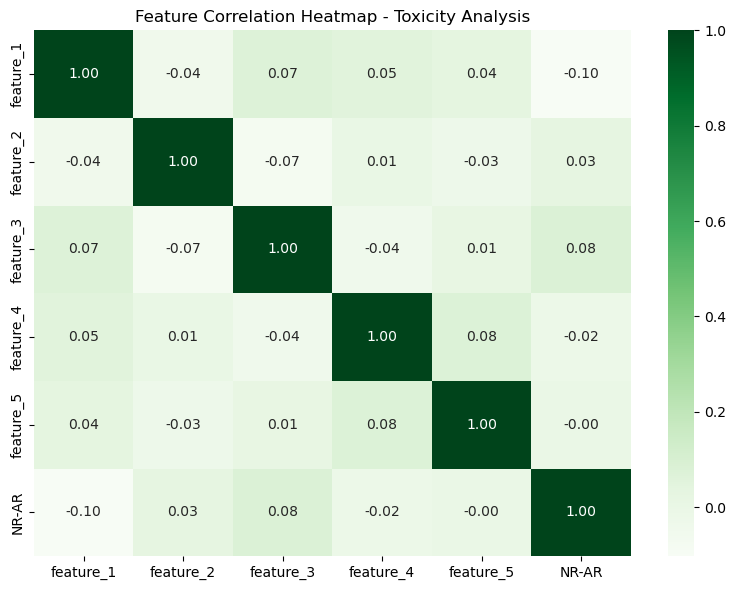

Heatmap saved!


In [17]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[['feature_1','feature_2',
            'feature_3','feature_4','feature_5',
            'NR-AR']].corr(), 
            annot=True, cmap='Greens', fmt='.2f')
plt.title('Feature Correlation Heatmap - Toxicity Analysis')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print("Heatmap saved!")